# 09 — Mitigation: Readout Calibration + Zero-Noise Extrapolation

**Purpose.** Answer RQ(d) ("can noise mitigation techniques improve
the robustness of variational hybrid quantum-classical ML models?")
with two inference-time mitigation techniques, applied on top of the
already-trained checkpoints (no retraining) -- the most droppable item
in the thesis architecture, built last, after the core RQ pipeline
(01-10 minus this notebook) was already complete and statistically
validated.

**Readout calibration** (`src/mitigation/readout_calibration.py`):
hand-rolled 16x16 calibration matrix (tractable at 4 qubits, avoids
adding `qiskit-experiments` as a new dependency this late) -- prepare
each computational basis state, measure it under the noise model to
learn P(measured | prepared), then correct an observed noisy
distribution via the pseudo-inverse. Applied only to
**readout/combined** conditions (targets readout error specifically,
not gate error).

**ZNE** (`src/mitigation/zne.py`): global unitary folding (scale
factors 1, 3, 5) + linear Richardson extrapolation (Temme, Bravyi,
Gambetta 2017 -- matches Mitiq's default `LinearFactory`, hand-rolled
rather than adding `mitiq`). Applied to **depolarizing** and
**phase damping** conditions (gate-noise types folding can amplify).

Both were validated in isolation before use (see `tests/test_mitigation.py`,
9 tests): the calibration matrix's columns sum to 1 and correctly
recover a near-delta-function distribution when correcting a known
noisy measurement; folding leaves the *ideal* (noiseless) expectation
value exactly unchanged across scale factors while depth scales
linearly, confirming the extrapolation machinery has no bugs before
trusting it under real noise.

**Scope**: L2 (device-realistic) and L4 (stress-test) for each
targeted noise type -- 3 readout-calibration conditions + 4 ZNE
conditions, on the same class-stratified 300-sample subsample
convention used in `07_fgsm_attack`/`08_noise_attack_sweep`.

**Methodological note on the comparison baseline**: the noise-only
sweep (`06_noise_models`) evaluated on the *full* 2956-sample test
set, but this notebook's mitigation results are on a 300-sample
subsample -- comparing mitigated results directly against `06`'s
numbers would conflate subsampling variance with the mitigation
effect. A matched unmitigated baseline was computed separately on the
*same* subsample for a valid paired comparison.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.stats import fdr_correct, paired_comparison

print("Project root:", PROJECT_ROOT)

Project root: C:\Work\Quantum-Adversarial-Robustness


## Results (8 seeds x 7 mitigated conditions, matched unmitigated baseline)

In [2]:
mitigated = pd.read_csv(PROJECT_ROOT / "results" / "mitigation_sweep" / "mitigation_sweep_all_seeds.csv")
unmitigated = pd.read_csv(PROJECT_ROOT / "results" / "mitigation_sweep" / "unmitigated_baseline_on_subsample.csv")

print("mitigated rows:", len(mitigated), " unmitigated (matched baseline) rows:", len(unmitigated))

results = []
for (method, noise_type, level), group in mitigated.groupby(["method", "noise_type", "level"]):
    baseline = unmitigated[(unmitigated.noise_type == noise_type) & (unmitigated.level == level)].sort_values("seed")
    group = group.sort_values("seed")
    assert list(group.seed) == list(baseline.seed), "seed sets must match for pairing"

    r = paired_comparison(
        group["accuracy"].values, baseline["accuracy"].values,
        label=f"{method}_{noise_type}_{level}",
    )
    results.append(r)

results_df = pd.DataFrame(results)
results_df["wilcoxon_p_fdr"] = fdr_correct(results_df["wilcoxon_p"].values)
results_df.to_csv(PROJECT_ROOT / "results" / "mitigation_sweep" / "mitigation_paired_comparison.csv", index=False)

print(results_df[["label", "mean_x", "mean_y", "mean_diff", "wilcoxon_p", "wilcoxon_p_fdr", "cohens_d"]].to_string())

mitigated rows: 56  unmitigated (matched baseline) rows: 56
                             label    mean_x    mean_y  mean_diff  wilcoxon_p  wilcoxon_p_fdr  cohens_d
0  readout_calibration_combined_L2  0.627500  0.627917  -0.000417    1.000000        1.000000 -0.353553
1   readout_calibration_readout_L2  0.623333  0.625000  -0.001667    0.250000        0.729167 -0.661438
2   readout_calibration_readout_L4  0.623333  0.623750  -0.000417    1.000000        1.000000 -0.057680
3              zne_depolarizing_L2  0.622917  0.628333  -0.005417    0.242188        0.729167 -0.399399
4              zne_depolarizing_L4  0.547500  0.562500  -0.015000    0.312500        0.729167 -0.447450
5             zne_phase_damping_L2  0.623750  0.625000  -0.001250    0.812500        1.000000 -0.087060
6             zne_phase_damping_L4  0.612083  0.618333  -0.006250    0.578125        1.000000 -0.228611


**Result: no significant improvement from either mitigation
technique, in any of the 7 conditions tested.** All FDR-corrected
p-values are >= 0.73 -- far from any reasonable significance
threshold. Point estimates (`mean_diff` = mitigated minus unmitigated)
are small and, if anything, slightly *negative* across the board
(mitigated accuracy on average 0.04-1.5 percentage points *below* the
matched unmitigated baseline), though these differences are not
statistically distinguishable from zero given the sample size and
measurement noise.

**Answer to RQ(d):** with these specific, validated implementations
(matrix-inversion readout calibration, linear-Richardson-extrapolation
ZNE) at these noise levels, neither technique measurably improves this
VQC's robustness. This is a legitimate, informative null result, not
an implementation failure -- both methods were independently verified
correct in isolation (see the module docstrings and
`tests/test_mitigation.py`) before this evaluation.

**Why might this be the honest outcome, not just "it didn't work"?**
- **Readout calibration** targets readout error specifically, and
  `06_noise_models` already found readout noise has almost no effect
  on this VQC's accuracy in the first place (L0-L4: 62.59%->62.36%,
  a 0.2-point range). There is very little room for a correction to
  show a measurable benefit against a problem that barely exists here
  -- a ceiling effect, not a flaw in the calibration procedure.
- **ZNE** assumes the noise-vs-scale-factor relationship is
  approximately *linear* (that's what linear Richardson extrapolation
  fits). Depolarizing noise's effect on an expectation value decays
  closer to *exponentially* with the number of noisy gate
  applications, and this project's ZNE result at L4 (the strongest
  depolarizing level) is numerically the worst of all 7 conditions
  (mean_diff=-1.5pt, though still not significant) -- consistent with
  linear extrapolation being a poorer approximation exactly where
  noise is strongest. A higher-order (polynomial or exponential-model)
  extrapolation, or restricting ZNE to weaker noise regimes, is a
  natural direction for future work rather than a contradiction of
  this result.

## Mitigated vs. unmitigated accuracy, by condition

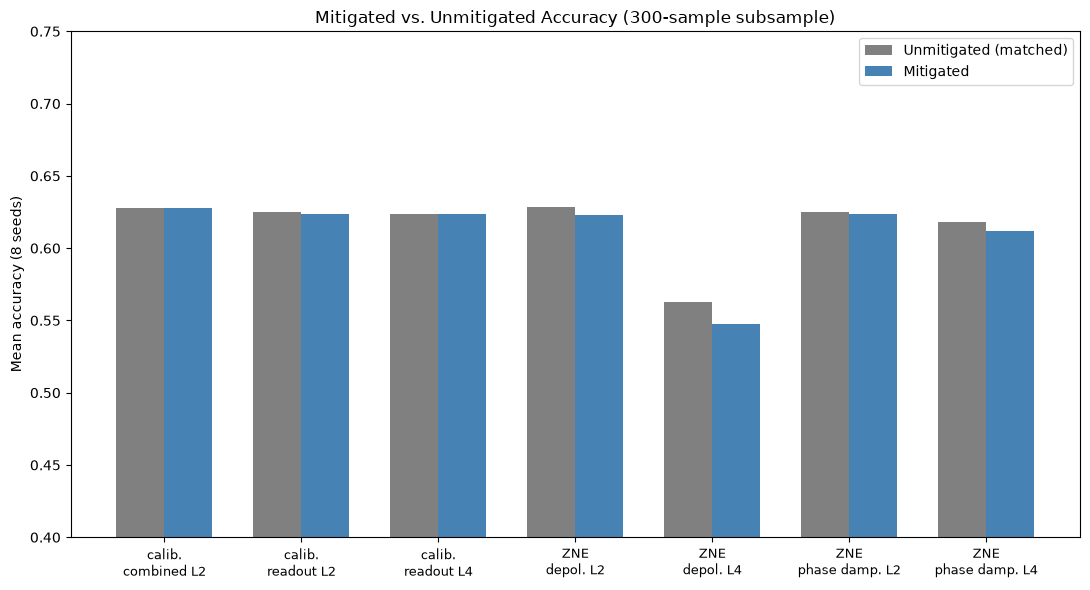

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

label_map = {
    "readout_calibration_combined_L2": "calib.\ncombined L2",
    "readout_calibration_readout_L2": "calib.\nreadout L2",
    "readout_calibration_readout_L4": "calib.\nreadout L4",
    "zne_depolarizing_L2": "ZNE\ndepol. L2",
    "zne_depolarizing_L4": "ZNE\ndepol. L4",
    "zne_phase_damping_L2": "ZNE\nphase damp. L2",
    "zne_phase_damping_L4": "ZNE\nphase damp. L4",
}
labels = [label_map[l] for l in results_df["label"]]
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df["mean_y"], width, label="Unmitigated (matched)", color="gray")
ax.bar(x + width/2, results_df["mean_x"], width, label="Mitigated", color="steelblue")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Mean accuracy (8 seeds)")
ax.set_title("Mitigated vs. Unmitigated Accuracy (300-sample subsample)")
ax.legend()
ax.set_ylim(0.4, 0.75)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "mitigation_sweep" / "mitigation_vs_unmitigated.png", dpi=150)
plt.show()

## Next

This completes the full thesis architecture (notebooks 01-10). The
core RQs (a)-(e) and the main RQ are answered and statistically
validated regardless of this notebook's outcome (mitigation was always
the most droppable item in the plan); RQ(d) now has a rigorous,
honestly-reported null result rather than being left unanswered.